# Cerebellar-stimulation cortical PSTH explorer

Browse lobules/FOVs, stimulation conditions, cortical units, and stimulation IDs. The stored traces are smoothed, z-scored PSTHs rather than raw firing rates in Hz.

> **Security:** only load pickle files that you trust; loading a pickle can execute Python code.

## 1. Optional installation
Uncomment and run this cell if your environment is missing any packages.

In [10]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# %pip install numpy pandas matplotlib ipywidgets

## 2. Imports and file path

In [12]:
from pathlib import Path
import pickle

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, clear_output

PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT /"data/stim_pckls/sg007/2025-06-02/sg007_2025-06-02_ch250-384_seshMatch.pkl"
DATA_PATH

PosixPath('/Users/alex/Desktop/Cajal2026/project/reach_v5/data/stim_pckls/sg007/2025-06-02/sg007_2025-06-02_ch250-384_seshMatch.pkl')

## 3. Load and validate the pickle
Both `stimFrameMatched` and the original `stimFrame` format are supported.

In [13]:
def load_psth_pickle(path):
    path = Path(path).expanduser()
    with path.open('rb') as handle:
        dataset = pickle.load(handle)

    if not isinstance(dataset, dict):
        raise ValueError('Expected a dictionary at the root of the pickle.')

    frame_key = next(
        (key for key in ('stimFrameMatched', 'stimFrame') if key in dataset),
        None,
    )
    if frame_key is None or not isinstance(dataset[frame_key], pd.DataFrame):
        raise ValueError('Could not find a stimFrame or stimFrameMatched DataFrame.')

    required = {'fov', 'paqName', 'stimName', 'iUnits', 'iChans', 'psthMat3d'}
    missing = required.difference(dataset[frame_key].columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    frame = dataset[frame_key].reset_index(drop=False).rename(
        columns={'index': 'source_row'}
    )
    return dataset, frame_key, frame


dataset, frame_key, stim_frame = load_psth_pickle(DATA_PATH)
print(f'Loaded {DATA_PATH.name}')
print(f'DataFrame: {frame_key}; shape: {stim_frame.shape}')

Loaded sg007_2025-06-02_ch250-384_seshMatch.pkl
DataFrame: stimFrameMatched; shape: (12, 20)


## 4. Dataset overview

In [14]:
overview = stim_frame[['source_row', 'fov', 'paqName', 'stimName']].copy()
overview['n_units'] = stim_frame['iUnits'].map(len)
overview['n_time_bins'] = stim_frame['psthMat3d'].map(lambda x: np.asarray(x).shape[1])
overview['n_stim_ids'] = stim_frame['psthMat3d'].map(lambda x: np.asarray(x).shape[2])
overview

,source_row,fov,paqName,stimName,n_units,n_time_bins,n_stim_ids
0,0,lob6,sg007_lob6_stim002,sg007_lob6_stim1131713,42,200,8
1,1,lob6,sg007_lob6_stim004,sg007_lob6_stim2135600,42,200,8
2,2,lob6,sg007_lob6_stim006,sg007_lob6_stim3141418,42,200,8
3,3,crus1,sg007_crus1_stim002,sg007_crus1_stim1144936,42,200,8
4,4,crus1,sg007_crus1_stim004,sg007_crus1_stim2151635,42,200,8
5,5,crus1,sg007_crus1_stim006,sg007_crus1_stim3153518,42,200,8
6,6,simlat,sg007_simlat_stim002,sg007_simlat_stim1160359,42,200,6
7,7,simlat,sg007_simlat_stim004,sg007_simlat_stim2162526,42,200,6
8,8,simlat,sg007_simlat_stim006,sg007_simlat_stim3164027,42,200,6
9,9,simmed,sg007_simmed_stim002,sg007_simmed_stim1172729,42,200,5


## 5. Trace extraction helpers
`psthMat3d` is indexed as **unit × time bin × stimulation ID**.

In [15]:
def time_axis_ms(row):
    n_bins = np.asarray(row['psthMat3d']).shape[1]
    params = row.get('psthParams', {})
    params = params if isinstance(params, dict) else {}
    window = params.get('psthw', [-200, 200])
    bin_ms = params.get('psthb')
    if bin_ms is not None:
        return float(window[0]) + np.arange(n_bins) * float(bin_ms)
    return np.linspace(float(window[0]), float(window[1]), n_bins, endpoint=False)


def get_trace(row_number, unit_id, stimulation_id):
    row = stim_frame.loc[int(row_number)]
    unit_ids = np.asarray(row['iUnits'], dtype=int)
    matches = np.flatnonzero(unit_ids == int(unit_id))
    if not len(matches):
        raise KeyError(f'Unit {unit_id} is not present in row {row_number}.')
    unit_index = int(matches[0])
    psth = np.asarray(row['psthMat3d'], dtype=float)
    stimulation_id = int(stimulation_id)
    if not 0 <= stimulation_id < psth.shape[2]:
        raise IndexError(f'Stimulation ID must be between 0 and {psth.shape[2] - 1}.')

    trace = psth[unit_index, :, stimulation_id]
    return pd.DataFrame({
        'time_ms': time_axis_ms(row),
        'psth_zscore': trace,
        'unit_id': int(unit_id),
        'channel': int(np.asarray(row['iChans'])[unit_index]),
        'fov': str(row['fov']),
        'condition': str(row['paqName']),
        'stim_name': str(row['stimName']),
        'stimulation_id': stimulation_id,
    })


def plot_trace(trace_table, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
    time = trace_table['time_ms'].to_numpy()
    trace = trace_table['psth_zscore'].to_numpy()
    peak = int(np.nanargmax(trace))
    trough = int(np.nanargmin(trace))
    meta = trace_table.iloc[0]

    ax.plot(time, trace, linewidth=1.8)
    ax.axvline(0, color='tab:red', linestyle='--', linewidth=1.2, label='stimulation')
    ax.axhline(0, color='0.45', linewidth=0.8)
    ax.scatter(time[peak], trace[peak], s=35, zorder=3)
    ax.set(
        xlabel='Time from stimulation onset (ms)',
        ylabel='PSTH (z-score)',
        title=(f"Unit {meta['unit_id']} · channel {meta['channel']} · {meta['fov']} · "
               f"stimulation ID {meta['stimulation_id']}"),
    )
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    print(
        f"Peak {trace[peak]:.2f} z at {time[peak]:+.0f} ms; "
        f"trough {trace[trough]:.2f} z at {time[trough]:+.0f} ms"
    )
    return ax

## 6. Interactive explorer
Change any dropdown to update the trace. Conditions and unit choices automatically follow the selected lobule/FOV.

In [16]:
fov_widget = widgets.Dropdown(
    options=stim_frame['fov'].astype(str).drop_duplicates().tolist(),
    description='Lobule/FOV:',
    style={'description_width': 'initial'},
)
row_widget = widgets.Dropdown(description='Condition:', style={'description_width': 'initial'})
unit_widget = widgets.Dropdown(description='Cortical unit:', style={'description_width': 'initial'})
stim_widget = widgets.Dropdown(description='Stimulation ID:', style={'description_width': 'initial'})
output = widgets.Output()


def update_rows(*_):
    rows = stim_frame.index[stim_frame['fov'].astype(str) == fov_widget.value].tolist()
    row_widget.options = [
        (f"row {stim_frame.loc[i, 'source_row']}: {stim_frame.loc[i, 'paqName']}", i)
        for i in rows
    ]


def update_units_and_stims(*_):
    if row_widget.value is None:
        return
    row = stim_frame.loc[row_widget.value]
    units = np.asarray(row['iUnits'], dtype=int)
    channels = np.asarray(row['iChans'], dtype=int)
    unit_widget.options = [
        (f'unit {unit} · channel {channel}', int(unit))
        for unit, channel in zip(units, channels)
    ]
    stim_widget.options = list(range(np.asarray(row['psthMat3d']).shape[2]))


def update_plot(*_):
    if row_widget.value is None or unit_widget.value is None or stim_widget.value is None:
        return
    with output:
        clear_output(wait=True)
        selected = get_trace(row_widget.value, unit_widget.value, stim_widget.value)
        plot_trace(selected)
        plt.show()


fov_widget.observe(update_rows, names='value')
row_widget.observe(update_units_and_stims, names='value')
row_widget.observe(update_plot, names='value')
unit_widget.observe(update_plot, names='value')
stim_widget.observe(update_plot, names='value')

update_rows()
update_units_and_stims()
update_plot()
display(widgets.VBox([fov_widget, row_widget, unit_widget, stim_widget]), output)

Output()

## 7. Extract or export a trace directly
This dataset-independent example selects the first unit and stimulation ID from the first row. Replace those three selections with any identifiers shown in the overview table.

,time_ms,psth_zscore,unit_id,channel,fov,condition,stim_name,stimulation_id
0,-500.0,-0.322744,913,284,lob6,sg007_lob6_stim002,sg007_lob6_stim1131713,0
1,-490.0,0.341692,913,284,lob6,sg007_lob6_stim002,sg007_lob6_stim1131713,0
2,-480.0,0.056764,913,284,lob6,sg007_lob6_stim002,sg007_lob6_stim1131713,0
3,-470.0,-0.284016,913,284,lob6,sg007_lob6_stim002,sg007_lob6_stim1131713,0
4,-460.0,-0.575948,913,284,lob6,sg007_lob6_stim002,sg007_lob6_stim1131713,0


Peak 1.41 z at +600 ms; trough -0.89 z at +100 ms


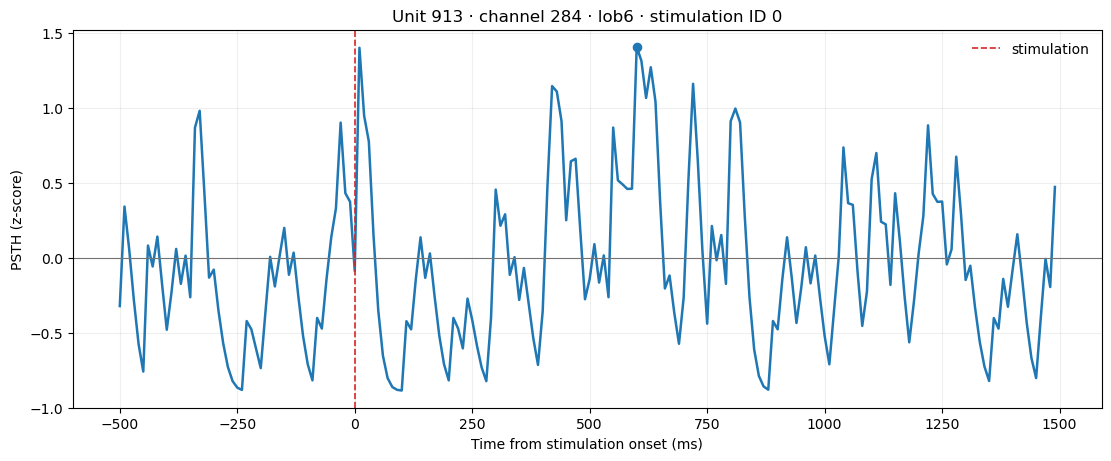

In [17]:
example_row = 0
example_unit = int(np.asarray(stim_frame.loc[example_row, 'iUnits'])[0])
example_stimulation_id = 0

example = get_trace(
    row_number=example_row,
    unit_id=example_unit,
    stimulation_id=example_stimulation_id,
)
display(example.head())
plot_trace(example)
plt.show()

In [18]:
# Export the selected example. Change the output path if desired.
example_meta = example.iloc[0]
OUTPUT_CSV = Path(
    f"unit-{example_meta['unit_id']}_{example_meta['fov']}_"
    f"stim-{example_meta['stimulation_id']}.csv"
)
example.to_csv(OUTPUT_CSV, index=False)
OUTPUT_CSV.resolve()

PosixPath('/Users/alex/Desktop/Cajal2026/project/reach_v5/unit-913_lob6_stim-0.csv')

## 8. Optional population comparisons
The following helper overlays one stimulation ID across multiple units from the same condition.

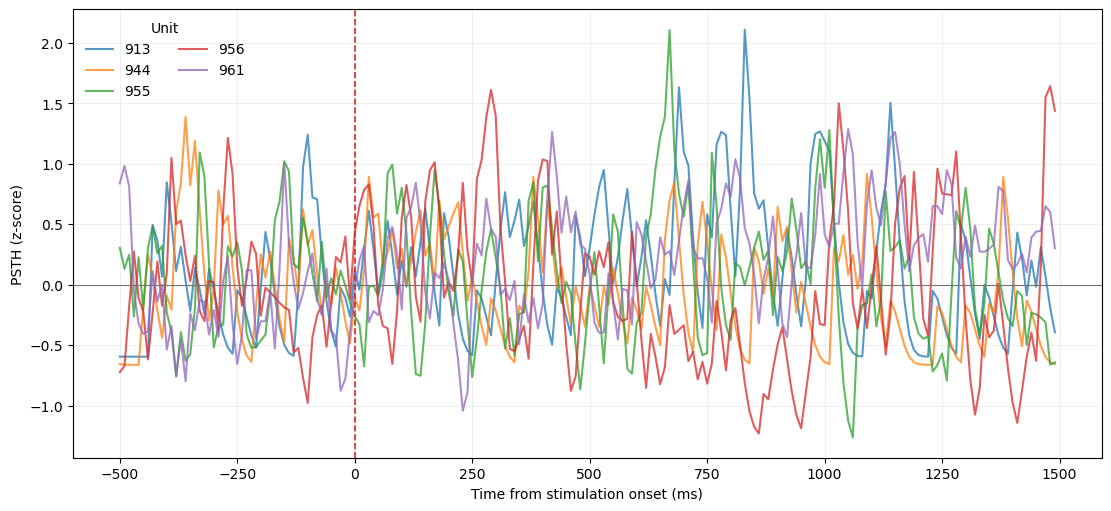

In [19]:
def plot_units(row_number, unit_ids, stimulation_id, alpha=0.75):
    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    for unit_id in unit_ids:
        table = get_trace(row_number, unit_id, stimulation_id)
        ax.plot(table['time_ms'], table['psth_zscore'], label=str(unit_id), alpha=alpha)
    ax.axvline(0, color='tab:red', linestyle='--', linewidth=1.2)
    ax.axhline(0, color='0.45', linewidth=0.8)
    ax.set(xlabel='Time from stimulation onset (ms)', ylabel='PSTH (z-score)')
    ax.grid(alpha=0.2)
    ax.legend(title='Unit', frameon=False, ncols=2)
    return ax


# Example: compare the first five units in row 2 during stimulation ID 1.
row_number = 2
first_five_units = np.asarray(stim_frame.loc[row_number, 'iUnits'])[:5]
plot_units(row_number, first_five_units, stimulation_id=1)
plt.show()

## 9. Population response to one stimulation location
Each heatmap row is one cortical unit and each column is one time bin. Units can be sorted by their mean response in a chosen post-stimulation window. The mean-response ranking is an exploratory effect-size measure, not by itself a significance test.

In [20]:
def population_response(row_number, stimulation_id, response_window=(0, 500), sort_by='absolute'):
    row = stim_frame.loc[int(row_number)]
    psth = np.asarray(row['psthMat3d'], dtype=float)
    stimulation_id = int(stimulation_id)
    if not 0 <= stimulation_id < psth.shape[2]:
        raise IndexError(f'Stimulation ID must be between 0 and {psth.shape[2] - 1}.')

    matrix = psth[:, :, stimulation_id]
    time = time_axis_ms(row)
    response_mask = (time >= response_window[0]) & (time < response_window[1])
    if not response_mask.any():
        raise ValueError('The response window does not overlap the saved PSTH window.')
    response_score = np.nanmean(matrix[:, response_mask], axis=1)

    if sort_by == 'absolute':
        order = np.argsort(-np.abs(response_score))
    elif sort_by == 'positive':
        order = np.argsort(-response_score)
    elif sort_by == 'negative':
        order = np.argsort(response_score)
    elif sort_by == 'unit ID':
        order = np.argsort(np.asarray(row['iUnits'], dtype=int))
    else:
        raise ValueError("sort_by must be 'absolute', 'positive', 'negative', or 'unit ID'.")

    units = np.asarray(row['iUnits'], dtype=int)
    channels = np.asarray(row['iChans'], dtype=int)
    ranking = pd.DataFrame({
        'unit_index': np.arange(len(units)),
        'unit_id': units,
        'channel': channels,
        'mean_response_z': response_score,
    })

    p_stim = row.get('pStim')
    if isinstance(p_stim, np.ndarray) and p_stim.shape == (len(units), psth.shape[2]):
        ranking['p_stim'] = p_stim[:, stimulation_id]
        ranking['p_below_0_05'] = ranking['p_stim'] < 0.05

    ranking = ranking.iloc[order].reset_index(drop=True)
    return {
        'row': row,
        'time': time,
        'matrix': matrix[order],
        'order': order,
        'ranking': ranking,
        'stimulation_id': stimulation_id,
        'response_window': response_window,
    }


def plot_population(result, color_limit=3):
    row = result['row']
    time = result['time']
    matrix = result['matrix']
    ranking = result['ranking']
    stim_id = result['stimulation_id']

    fig, (heat_ax, mean_ax) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True,
        gridspec_kw={'height_ratios': [4, 1]}, constrained_layout=True,
    )
    image = heat_ax.imshow(
        matrix, aspect='auto', interpolation='nearest', cmap='RdBu_r',
        vmin=-color_limit, vmax=color_limit,
        extent=[time[0], time[-1] + np.median(np.diff(time)), len(matrix), 0],
    )
    heat_ax.axvline(0, color='black', linestyle='--', linewidth=1)
    heat_ax.set_ylabel('Cortical units (sorted rows)')
    heat_ax.set_title(
        f"{row['fov']} · {row['paqName']} · stimulation ID {stim_id} · {len(matrix)} units"
    )
    colorbar = fig.colorbar(image, ax=heat_ax, pad=0.01)
    colorbar.set_label('PSTH (z-score)')

    population_mean = np.nanmean(matrix, axis=0)
    population_sem = np.nanstd(matrix, axis=0, ddof=1) / np.sqrt(len(matrix))
    mean_ax.plot(time, population_mean, color='tab:blue', linewidth=1.8)
    mean_ax.fill_between(
        time, population_mean - population_sem, population_mean + population_sem,
        color='tab:blue', alpha=0.2, linewidth=0, label='mean ± SEM',
    )
    mean_ax.axvline(0, color='tab:red', linestyle='--', linewidth=1)
    mean_ax.axhline(0, color='0.45', linewidth=0.8)
    mean_ax.set(xlabel='Time from stimulation onset (ms)', ylabel='Mean z')
    mean_ax.legend(frameon=False)

    if 'p_below_0_05' in ranking:
        print(f"Saved pStim < 0.05: {ranking['p_below_0_05'].sum()} / {len(ranking)} units")
    return fig


def plot_top_responders(result, n=6):
    row = result['row']
    time = result['time']
    ranking = result['ranking'].head(n)
    original_matrix = np.asarray(row['psthMat3d'], dtype=float)[:, :, result['stimulation_id']]
    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    for _, unit in ranking.iterrows():
        trace = original_matrix[int(unit['unit_index'])]
        ax.plot(time, trace, label=f"{int(unit['unit_id'])} ({unit['mean_response_z']:+.2f} z)")
    ax.axvline(0, color='tab:red', linestyle='--', linewidth=1.2)
    ax.axhline(0, color='0.45', linewidth=0.8)
    ax.set(
        xlabel='Time from stimulation onset (ms)', ylabel='PSTH (z-score)',
        title=f"Top {len(ranking)} units by absolute mean response",
    )
    ax.grid(alpha=0.2)
    ax.legend(title='Unit ID (window mean)', frameon=False, ncols=2)
    return fig

### Interactive population view
For the older `dk044` file, row 7 / stimulation ID 2 is a useful example: 19 of 92 units have saved `pStim < 0.05`. Change the selectors to examine every recording and stimulation location.

In [21]:
population_row = widgets.Dropdown(
    options=[
        (f"row {r.source_row}: {r.fov} · {r.paqName}", i)
        for i, r in stim_frame.iterrows()
    ],
    value=min(7, len(stim_frame) - 1),
    description='Condition:',
    style={'description_width': 'initial'},
)
population_stim = widgets.Dropdown(
    description='Stimulation ID:', style={'description_width': 'initial'}
)
population_sort = widgets.Dropdown(
    options=['absolute', 'positive', 'negative', 'unit ID'],
    value='absolute', description='Sort units:',
    style={'description_width': 'initial'},
)
population_output = widgets.Output()


def update_population_stims(*_):
    row = stim_frame.loc[population_row.value]
    population_stim.options = list(range(np.asarray(row['psthMat3d']).shape[2]))
    if len(population_stim.options) > 2:
        population_stim.value = 2


def update_population_plot(*_):
    if population_stim.value is None:
        return
    with population_output:
        clear_output(wait=True)
        result = population_response(
            population_row.value, population_stim.value,
            response_window=(0, 500), sort_by=population_sort.value,
        )
        display(result['ranking'].head(10))
        plot_population(result)
        plt.show()
        plot_top_responders(result, n=6)
        plt.show()


population_row.observe(update_population_stims, names='value')
population_row.observe(update_population_plot, names='value')
population_stim.observe(update_population_plot, names='value')
population_sort.observe(update_population_plot, names='value')
update_population_stims()
update_population_plot()
display(
    widgets.HBox([population_row, population_stim, population_sort]),
    population_output,
)

Output()

### Programmatic example and matrix export

,unit_index,unit_id,channel,mean_response_z
0,10,1025,315,1.052243
1,3,956,295,0.819258
2,9,1024,314,0.761379
3,11,1039,317,0.626786
4,36,1296,274,-0.577111
5,4,961,298,0.561863
6,7,982,304,0.534163
7,39,1415,281,0.440695
8,29,1211,361,-0.313825
9,35,1294,377,0.306025


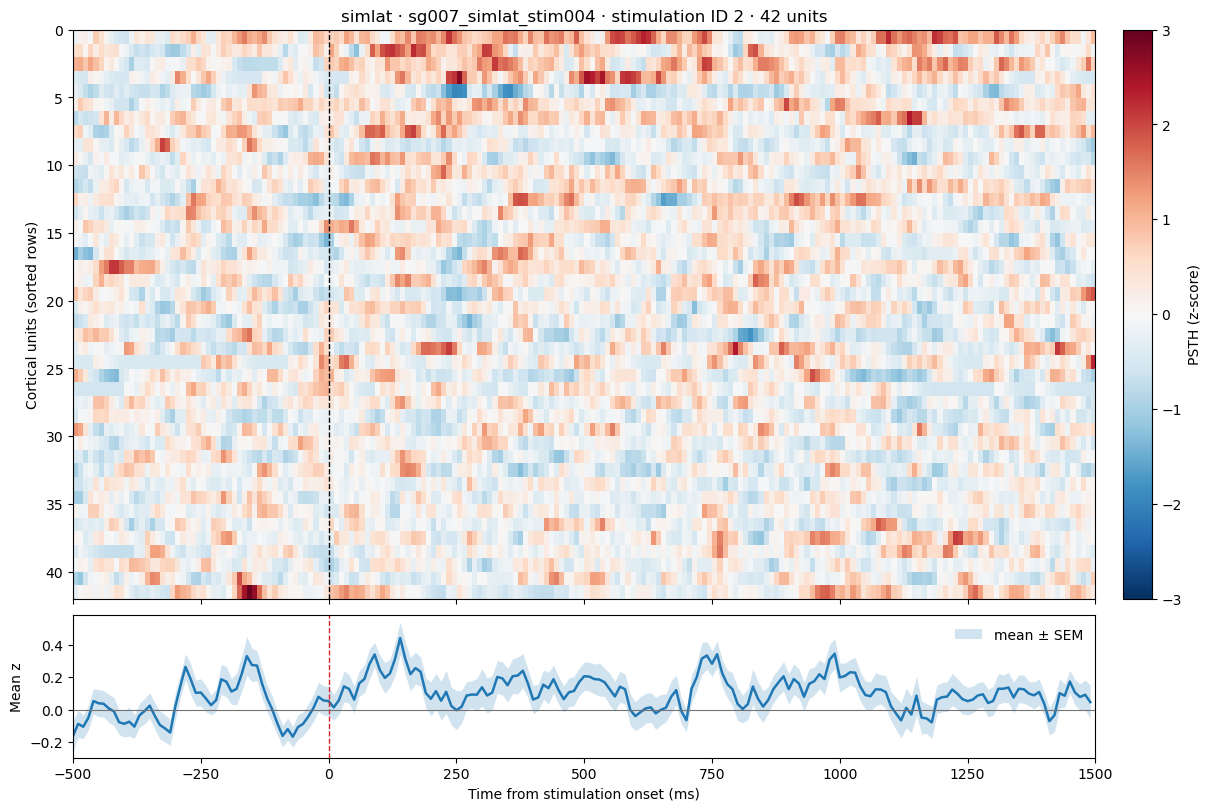

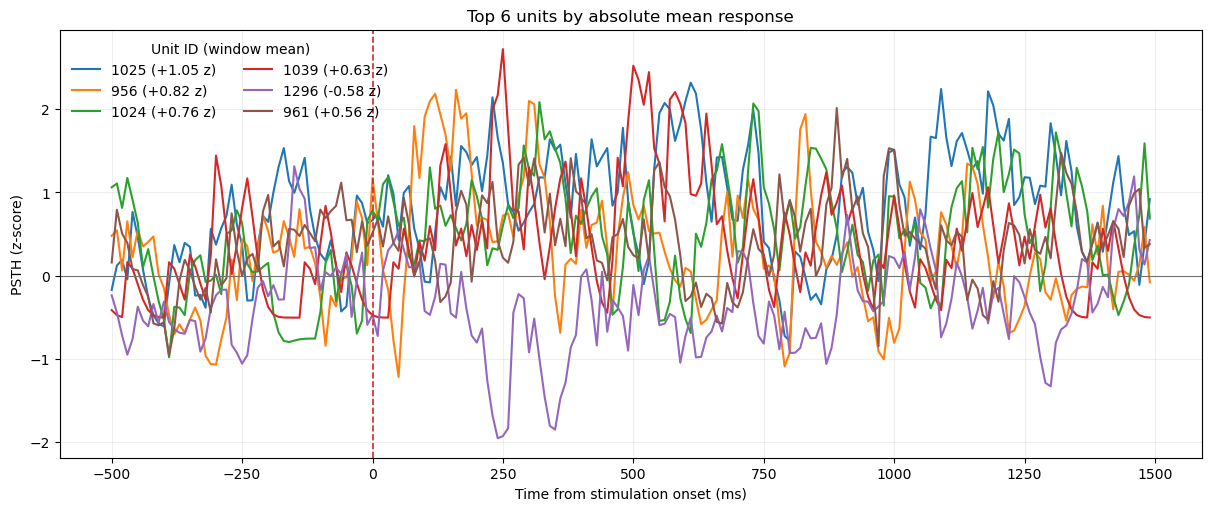

(42, 200)

In [22]:
selected_row = min(7, len(stim_frame) - 1)
selected_stim = min(2, np.asarray(stim_frame.loc[selected_row, 'psthMat3d']).shape[2] - 1)
population = population_response(
    selected_row, selected_stim, response_window=(0, 500), sort_by='absolute'
)
display(population['ranking'].head(10))
plot_population(population)
plt.show()
plot_top_responders(population, n=6)
plt.show()

# Save the sorted unit × time population matrix with unit IDs as row labels.
population_table = pd.DataFrame(
    population['matrix'],
    index=population['ranking']['unit_id'],
    columns=population['time'],
)
population_table.index.name = 'unit_id'
population_table.columns.name = 'time_ms'
population_table.to_csv('population_unit-by-time_matrix.csv')
population_table.shape

## 10. Unit-by-stimulation response barcode
For each cortical unit and stimulation ID, this analysis averages the PSTH z-score from stimulation onset until the end of the stimulation train. The resulting matrix has cortical units as rows and stimulation IDs as columns.

For multi-pulse trains, duration is derived from `numReps / repRate` and checked against `stimDur`. For single pulses with missing or zero frequency, `stimDur` is used as the pulse duration. Because older and newer files use different duration units, automatic inference can be overridden with the duration-unit selector. At least one complete PSTH bin is always included.

In [23]:
def stimulation_duration_ms(row, duration_units='auto', bin_ms=None):
    duration_value = pd.to_numeric(pd.Series([row.get('stimDur')]), errors='coerce').iloc[0]
    repetitions = pd.to_numeric(pd.Series([row.get('numReps')]), errors='coerce').iloc[0]
    frequency_hz = pd.to_numeric(pd.Series([row.get('repRate')]), errors='coerce').iloc[0]

    is_train = (
        np.isfinite(repetitions) and repetitions > 1
        and np.isfinite(frequency_hz) and frequency_hz > 0
    )
    derived_s = repetitions / frequency_hz if is_train else np.nan

    if duration_units not in {'auto', 'seconds', 'milliseconds'}:
        raise ValueError("duration_units must be 'auto', 'seconds', or 'milliseconds'.")

    if is_train and duration_units == 'auto':
        # Train duration is unambiguous when pulse count and frequency are present.
        duration_ms = float(derived_s) * 1000.0
        source = 'numReps / repRate'
        inferred_units = 'seconds'
    else:
        if not np.isfinite(duration_value) or duration_value <= 0:
            if is_train:
                duration_ms = float(derived_s) * 1000.0
                source = 'numReps / repRate'
                inferred_units = 'seconds'
            else:
                raise ValueError('No usable single-pulse duration in stimDur.')
        else:
            if duration_units == 'milliseconds':
                inferred_units = 'milliseconds'
            elif duration_units == 'seconds':
                inferred_units = 'seconds'
            elif is_train:
                inferred_units = 'seconds'
            else:
                # In these newer single-shot files stimDur=1 denotes a short pulse,
                # whereas the older train files store fractional seconds.
                inferred_units = 'milliseconds' if duration_value >= 1 else 'seconds'
            duration_ms = (
                float(duration_value)
                if inferred_units == 'milliseconds'
                else float(duration_value) * 1000.0
            )
            source = 'stimDur'

    if bin_ms is not None and np.isfinite(bin_ms) and bin_ms > 0:
        duration_ms = max(duration_ms, float(bin_ms))

    duration_from_field_s = (
        float(duration_value) if np.isfinite(duration_value) and duration_value > 0 else np.nan
    )
    consistent = (
        not is_train or not np.isfinite(duration_from_field_s)
        or np.isclose(duration_from_field_s, derived_s, rtol=0.05, atol=0.001)
    )
    return {
        'duration_ms': float(duration_ms),
        'duration_s': float(duration_ms) / 1000.0,
        'raw_stimDur': float(duration_value) if np.isfinite(duration_value) else None,
        'duration_units': inferred_units,
        'source': source,
        'is_train': bool(is_train),
        'derived_s': float(derived_s) if np.isfinite(derived_s) else None,
        'consistent': bool(consistent),
        'num_reps': int(repetitions) if np.isfinite(repetitions) else None,
        'frequency_hz': float(frequency_hz) if np.isfinite(frequency_hz) else None,
    }


def stimulation_barcode(
    row_number, responders='pStim < 0.05', sort_by='preferred stimulation',
    response_start_ms=0, duration_units='auto',
):
    row = stim_frame.loc[int(row_number)]
    psth = np.asarray(row['psthMat3d'], dtype=float)
    time = time_axis_ms(row)
    bin_ms = float(np.median(np.diff(time)))
    timing = stimulation_duration_ms(row, duration_units=duration_units, bin_ms=bin_ms)

    saved_end_ms = float(time[-1] + np.median(np.diff(time)))
    requested_end_ms = timing['duration_ms']
    used_end_ms = min(max(requested_end_ms, response_start_ms + bin_ms), saved_end_ms)
    mask = (time >= response_start_ms) & (time < used_end_ms)
    if not mask.any():
        raise ValueError('The stimulation window does not overlap the saved PSTH bins.')

    # Average across time, preserving unit × stimulation-ID axes.
    response = np.nanmean(psth[:, mask, :], axis=1)
    units = np.asarray(row['iUnits'], dtype=int)
    channels = np.asarray(row['iChans'], dtype=int)
    p_stim = row.get('pStim')
    has_p_stim = isinstance(p_stim, np.ndarray) and p_stim.shape == response.shape

    if responders == 'pStim < 0.05':
        if not has_p_stim:
            raise ValueError('This row has no pStim matrix aligned to its units and stimulations.')
        keep = np.any(p_stim < 0.05, axis=1)
    elif responders == '|mean z| >= 0.5':
        keep = np.any(np.abs(response) >= 0.5, axis=1)
    elif responders == 'all units':
        keep = np.ones(len(units), dtype=bool)
    else:
        raise ValueError('Unknown responder filter.')

    response = response[keep]
    kept_units = units[keep]
    kept_channels = channels[keep]
    kept_p = p_stim[keep] if has_p_stim else None

    if sort_by == 'preferred stimulation':
        preferred = np.argmax(np.abs(response), axis=1)
        magnitude = np.max(np.abs(response), axis=1)
        order = np.lexsort((-magnitude, preferred))
    elif sort_by == 'response magnitude':
        order = np.argsort(-np.max(np.abs(response), axis=1))
    elif sort_by == 'unit ID':
        order = np.argsort(kept_units)
    elif sort_by == 'channel':
        order = np.argsort(kept_channels)
    else:
        raise ValueError('Unknown barcode sort mode.')

    response = response[order]
    kept_units = kept_units[order]
    kept_channels = kept_channels[order]
    kept_p = kept_p[order] if kept_p is not None else None
    return {
        'row': row, 'matrix': response, 'unit_ids': kept_units,
        'channels': kept_channels, 'p_stim': kept_p, 'timing': timing,
        'requested_end_ms': requested_end_ms, 'used_end_ms': used_end_ms,
        'response_start_ms': float(response_start_ms),
        'n_all_units': len(units), 'responder_filter': responders,
    }


def plot_stimulation_barcode(result, color_limit=None, mark_significant=True):
    matrix = result['matrix']
    row = result['row']
    if not len(matrix):
        raise ValueError('No units passed the selected responder filter.')
    if color_limit is None:
        color_limit = max(0.5, float(np.nanpercentile(np.abs(matrix), 98)))

    height = max(5, min(14, 2.5 + 0.16 * len(matrix)))
    fig, ax = plt.subplots(figsize=(9, height), constrained_layout=True)
    image = ax.imshow(
        matrix, aspect='auto', interpolation='nearest', cmap='RdBu_r',
        vmin=-color_limit, vmax=color_limit,
    )
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels([f'{i}' for i in range(matrix.shape[1])])
    ax.set_xlabel('Stimulation ID / location')
    ax.set_ylabel('Motor-cortex unit')

    if len(matrix) <= 60:
        ax.set_yticks(np.arange(len(matrix)))
        ax.set_yticklabels(result['unit_ids'])
    else:
        tick_rows = np.unique(np.linspace(0, len(matrix) - 1, 15, dtype=int))
        ax.set_yticks(tick_rows)
        ax.set_yticklabels(result['unit_ids'][tick_rows])

    if mark_significant and result['p_stim'] is not None:
        significant_y, significant_x = np.where(result['p_stim'] < 0.05)
        ax.scatter(
            significant_x, significant_y, marker='o', s=13,
            facecolors='none', edgecolors='black', linewidths=0.6,
            label='pStim < 0.05',
        )
        if len(significant_x):
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

    timing = result['timing']
    title = (
        f"{row['fov']} · {row['paqName']} · average {result['response_start_ms']:.0f}–"
        f"{result['used_end_ms']:.0f} ms · {len(matrix)}/{result['n_all_units']} units"
    )
    ax.set_title(title)
    colorbar = fig.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label('Mean PSTH change during stimulation (z-score)')
    return fig


def barcode_table(result):
    columns = [f'stim_{i}' for i in range(result['matrix'].shape[1])]
    table = pd.DataFrame(result['matrix'], columns=columns)
    table.insert(0, 'channel', result['channels'])
    table.insert(0, 'unit_id', result['unit_ids'])
    return table

### Interactive barcode explorer
Open circles mark unit–stimulation pairs with saved `pStim < 0.05`. The cell color is the signed mean z-score during the stimulation train.

In [24]:
barcode_row = widgets.Dropdown(
    options=[
        (
            f"row {r.source_row}: {r.fov} · {r.paqName} · "
            f"{r.numReps} pulse(s) at {r.repRate} Hz (stimDur={r.stimDur:g})",
            i,
        )
        for i, r in stim_frame.iterrows()
    ],
    description='Recording:', style={'description_width': 'initial'},
)
barcode_filter = widgets.Dropdown(
    options=['pStim < 0.05', '|mean z| >= 0.5', 'all units'],
    value='pStim < 0.05', description='Show units:',
    style={'description_width': 'initial'},
)
barcode_sort = widgets.Dropdown(
    options=['preferred stimulation', 'response magnitude', 'unit ID', 'channel'],
    value='preferred stimulation', description='Sort rows:',
    style={'description_width': 'initial'},
)
barcode_duration_units = widgets.Dropdown(
    options=['auto', 'milliseconds', 'seconds'], value='auto',
    description='stimDur units:', style={'description_width': 'initial'},
)
barcode_output = widgets.Output()


def update_barcode(*_):
    with barcode_output:
        clear_output(wait=True)
        result = stimulation_barcode(
            barcode_row.value, responders=barcode_filter.value,
            sort_by=barcode_sort.value, duration_units=barcode_duration_units.value,
        )
        timing = result['timing']
        frequency_text = (
            f"{timing['frequency_hz']:g} Hz"
            if timing['frequency_hz'] is not None and timing['frequency_hz'] > 0
            else 'single pulse; frequency not applicable'
        )
        print(
            f"Timing: {timing['num_reps']} pulse(s); {frequency_text}; "
            f"averaging duration {timing['duration_ms']:g} ms "
            f"from {timing['source']} ({timing['duration_units']})."
        )
        if timing['is_train']:
            print(f"Train metadata consistent: {timing['consistent']}")
        if result['used_end_ms'] < result['requested_end_ms']:
            print(
                f"Warning: requested end {result['requested_end_ms']:.0f} ms was clipped "
                f"to the saved PSTH end {result['used_end_ms']:.0f} ms."
            )
        display(barcode_table(result))
        plot_stimulation_barcode(result)
        plt.show()


barcode_row.observe(update_barcode, names='value')
barcode_filter.observe(update_barcode, names='value')
barcode_sort.observe(update_barcode, names='value')
barcode_duration_units.observe(update_barcode, names='value')
update_barcode()
display(
    widgets.VBox([
        barcode_row,
        widgets.HBox([barcode_filter, barcode_sort, barcode_duration_units]),
    ]),
    barcode_output,
)

Output()

### Programmatic barcode example and export

In [30]:
barcode = stimulation_barcode(
    row_number=0, responders='pStim < 0.05', sort_by='preferred stimulation'
)
plot_stimulation_barcode(barcode)
plt.show()

barcode_values = barcode_table(barcode)
display(barcode_values)
barcode_values.to_csv('unit-by-stimulation_barcode.csv', index=False)

ValueError: This row has no pStim matrix aligned to its units and stimulations.

## 11. Population-trajectory PCA for each stimulation
The saved arrays do **not** contain a repetition/trial axis, so this is PCA of the repetition-averaged population PSTHs rather than true trial-by-trial PCA. Each observation is one time bin from one stimulation ID, and each feature is one cortical unit.

A single PCA basis is fitted jointly across all stimulation IDs, allowing trajectories to be compared in the same PC1–PC2 space. Each stimulation is then plotted in its own panel. The highlighted portion is the stimulation train; optional pre- and post-stimulation context shows how the population enters and leaves the response state.

In [26]:
def population_trajectory_pca(
    row_number, pre_context_ms=50, post_context_ms=100,
    duration_units='auto', fit_window='displayed window',
):
    row = stim_frame.loc[int(row_number)]
    psth = np.asarray(row['psthMat3d'], dtype=float)  # units × time × stimulations
    time = time_axis_ms(row)
    bin_ms = float(np.median(np.diff(time)))
    timing = stimulation_duration_ms(row, duration_units=duration_units, bin_ms=bin_ms)
    saved_end_ms = float(time[-1] + bin_ms)
    stimulation_end_ms = min(timing['duration_ms'], saved_end_ms)
    display_start_ms = max(float(time[0]), -float(pre_context_ms))
    display_end_ms = min(saved_end_ms, stimulation_end_ms + float(post_context_ms))
    display_mask = (time >= display_start_ms) & (time < display_end_ms)

    if fit_window == 'displayed window':
        fit_mask = display_mask
    elif fit_window == 'entire saved PSTH':
        fit_mask = np.ones(len(time), dtype=bool)
    elif fit_window == 'stimulation only':
        fit_mask = (time >= 0) & (time < stimulation_end_ms)
    else:
        raise ValueError('Unknown PCA fit window.')

    if fit_mask.sum() * psth.shape[2] < 3:
        raise ValueError(
            'Too few population states for two-PC PCA. Add post-stimulation context '
            'or fit using the displayed/entire PSTH window.'
        )

    # Concatenate stimulation × time observations; cortical units are features.
    fit_data = psth[:, fit_mask, :].transpose(2, 1, 0).reshape(-1, psth.shape[0])
    feature_mean = np.nanmean(fit_data, axis=0)
    fit_data = np.where(np.isfinite(fit_data), fit_data, feature_mean)
    centered = fit_data - feature_mean
    _, singular_values, components = np.linalg.svd(centered, full_matrices=False)
    components = components[:2]
    variance = singular_values ** 2
    explained = variance[:2] / variance.sum() if variance.sum() else np.zeros(2)

    trajectories = []
    for stimulation_id in range(psth.shape[2]):
        states = psth[:, display_mask, stimulation_id].T
        states = np.where(np.isfinite(states), states, feature_mean)
        scores = (states - feature_mean) @ components.T
        trajectories.append(scores)

    return {
        'row': row, 'time': time[display_mask], 'trajectories': trajectories,
        'components': components, 'explained_variance_ratio': explained,
        'timing': timing, 'stimulation_end_ms': stimulation_end_ms,
        'display_start_ms': display_start_ms, 'display_end_ms': display_end_ms,
        'fit_window': fit_window, 'n_units': psth.shape[0],
    }


def plot_population_trajectories(result, columns=3):
    trajectories = result['trajectories']
    time = result['time']
    n_stimulations = len(trajectories)
    columns = min(int(columns), n_stimulations)
    rows = int(np.ceil(n_stimulations / columns))
    fig, axes = plt.subplots(
        rows, columns, figsize=(4.4 * columns, 4.1 * rows),
        squeeze=False, constrained_layout=True,
    )
    axes = axes.ravel()
    all_scores = np.concatenate(trajectories, axis=0)
    x_pad = max(np.ptp(all_scores[:, 0]) * 0.08, 0.05)
    y_pad = max(np.ptp(all_scores[:, 1]) * 0.08, 0.05)
    x_limits = (all_scores[:, 0].min() - x_pad, all_scores[:, 0].max() + x_pad)
    y_limits = (all_scores[:, 1].min() - y_pad, all_scores[:, 1].max() + y_pad)
    stimulation_mask = (time >= 0) & (time < result['stimulation_end_ms'])

    scatter = None
    for stimulation_id, (ax, scores) in enumerate(zip(axes, trajectories)):
        ax.plot(scores[:, 0], scores[:, 1], color='0.65', linewidth=1, zorder=1)
        scatter = ax.scatter(
            scores[:, 0], scores[:, 1], c=time, cmap='viridis', s=22, zorder=2,
            vmin=time.min(), vmax=time.max(),
        )
        if stimulation_mask.any():
            ax.plot(
                scores[stimulation_mask, 0], scores[stimulation_mask, 1],
                color='tab:red', linewidth=3, alpha=0.8, label='stimulation period',
            )
        start_index = int(np.argmin(np.abs(time)))
        ax.scatter(
            scores[start_index, 0], scores[start_index, 1], marker='o', s=60,
            facecolors='none', edgecolors='black', linewidths=1.2, zorder=4,
            label='onset',
        )
        ax.scatter(
            scores[-1, 0], scores[-1, 1], marker='X', s=50, color='black',
            zorder=4, label='display end',
        )
        ax.set(xlim=x_limits, ylim=y_limits, title=f'Stimulation {stimulation_id}')
        ax.set_xlabel(f"PC1 ({result['explained_variance_ratio'][0] * 100:.1f}%)")
        ax.set_ylabel(f"PC2 ({result['explained_variance_ratio'][1] * 100:.1f}%)")
        ax.grid(alpha=0.18)

    for ax in axes[n_stimulations:]:
        ax.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='outside upper right', frameon=False)
    if scatter is not None:
        colorbar = fig.colorbar(scatter, ax=axes[:n_stimulations], shrink=0.8, pad=0.02)
        colorbar.set_label('Time from stimulation onset (ms)')
    row = result['row']
    fig.suptitle(
        f"{row['fov']} · {row['paqName']} · {result['n_units']} cortical units · "
        f"joint PCA fitted on {result['fit_window']}",
    )
    return fig


def trajectory_table(result):
    tables = []
    for stimulation_id, scores in enumerate(result['trajectories']):
        tables.append(pd.DataFrame({
            'stimulation_id': stimulation_id, 'time_ms': result['time'],
            'pc1': scores[:, 0], 'pc2': scores[:, 1],
            'during_stimulation': (
                (result['time'] >= 0)
                & (result['time'] < result['stimulation_end_ms'])
            ),
        }))
    return pd.concat(tables, ignore_index=True)

### Interactive PCA trajectories
For a single-shot stimulation, keep post-stimulation context above zero; otherwise the stimulation itself may contain only one sampled population state.

In [ ]:
pca_row = widgets.Dropdown(
    options=[
        (f"row {r.source_row}: {r.fov} · {r.paqName}", i)
        for i, r in stim_frame.iterrows()
    ],
    description='Recording:', style={'description_width': 'initial'},
)
pca_fit_window = widgets.Dropdown(
    options=['displayed window', 'entire saved PSTH', 'stimulation only'],
    value='displayed window', description='Fit PCA on:',
    style={'description_width': 'initial'},
)
pca_duration_units = widgets.Dropdown(
    options=['auto', 'milliseconds', 'seconds'], value='auto',
    description='stimDur units:', style={'description_width': 'initial'},
)
pca_pre = widgets.IntSlider(
    value=50, min=0, max=500, step=10, description='Pre-context (ms):',
    continuous_update=False, style={'description_width': 'initial'},
)
pca_post = widgets.IntSlider(
    value=100, min=0, max=1000, step=10, description='Post-context (ms):',
    continuous_update=False, style={'description_width': 'initial'},
)
pca_output = widgets.Output()


def update_pca_trajectories(*_):
    with pca_output:
        clear_output(wait=True)
        try:
            result = population_trajectory_pca(
                pca_row.value, pre_context_ms=pca_pre.value,
                post_context_ms=pca_post.value,
                duration_units=pca_duration_units.value,
                fit_window=pca_fit_window.value,
            )
            explained = result['explained_variance_ratio'] * 100
            print(
                f"PC1 + PC2 explain {explained.sum():.1f}% "
                f"({explained[0]:.1f}% + {explained[1]:.1f}%). "
                f"Stimulation end: {result['stimulation_end_ms']:g} ms."
            )
            plot_population_trajectories(result)
            plt.show()
        except Exception as error:
            print(f'Could not compute PCA: {error}')


for control in [pca_row, pca_fit_window, pca_duration_units, pca_pre, pca_post]:
    control.observe(update_pca_trajectories, names='value')
update_pca_trajectories()
display(
    widgets.VBox([
        widgets.HBox([pca_row, pca_fit_window, pca_duration_units]),
        widgets.HBox([pca_pre, pca_post]),
    ]),
    pca_output,
)

Output()

### Programmatic PCA example and export

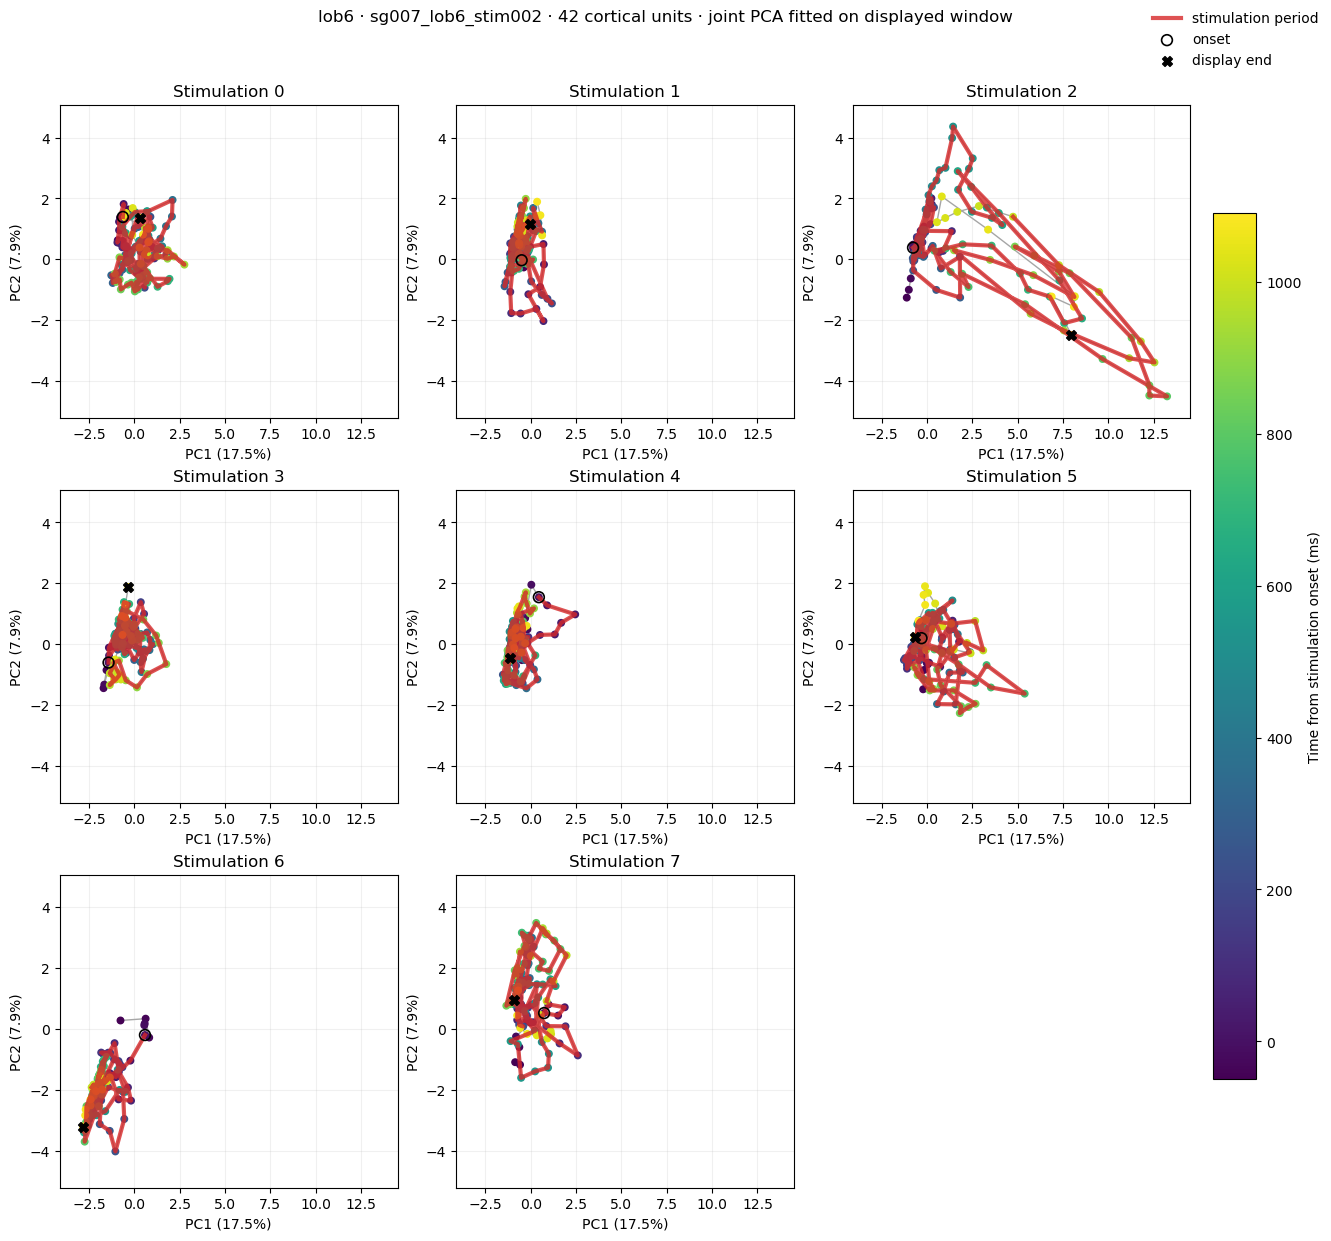

,stimulation_id,time_ms,pc1,pc2,during_stimulation
0,0,-50.0,-0.811093,0.532540,False
1,0,-40.0,-0.911159,0.625161,False
2,0,-30.0,-0.329141,1.634576,False
3,0,-20.0,-0.585322,1.306507,False
4,0,-10.0,-0.720891,1.398765,False


In [28]:
pca_result = population_trajectory_pca(
    row_number=0, pre_context_ms=50, post_context_ms=100,
    duration_units='auto', fit_window='displayed window',
)
plot_population_trajectories(pca_result)
plt.show()

pca_scores = trajectory_table(pca_result)
display(pca_scores.head())
pca_scores.to_csv('population_pca_trajectories.csv', index=False)